In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Read the dataset
df=pd.read_csv("B:/SELF_LEARNING/data/height-weight.csv")

In [ ]:
# Top 5 rows
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


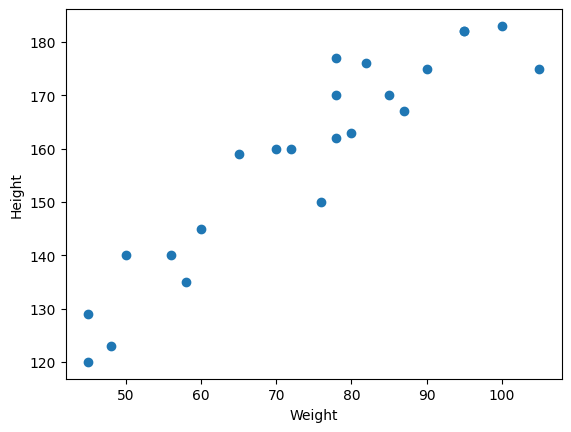

In [8]:
# Scatter Plot
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [15]:
# Divide the Dataset based on Independent and Dependent Feature
X=df[["Weight"]] # Independent Feature
y=df["Height"] # Dependent Feature

In [18]:
## Train and Test Split the Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [22]:
## Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

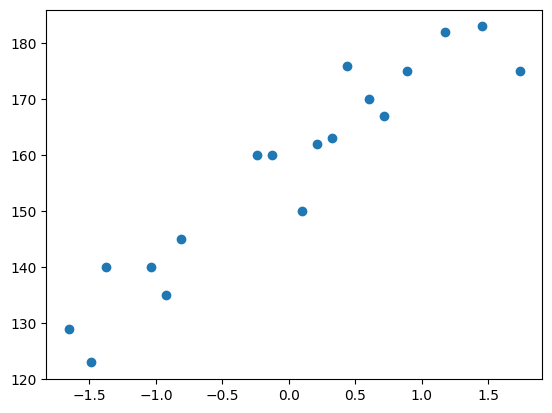

In [28]:
plt.scatter(X_train,y_train)

In [48]:
## Train Simple Linear Regression
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

regressor.fit(X_train,y_train)

print("Slope or coeffient of Weight is: ",regressor.coef_)
print("Intercept: ",regressor.intercept_)


Slope or coeffient of Weight is:  [17.03440872]
Intercept:  157.5


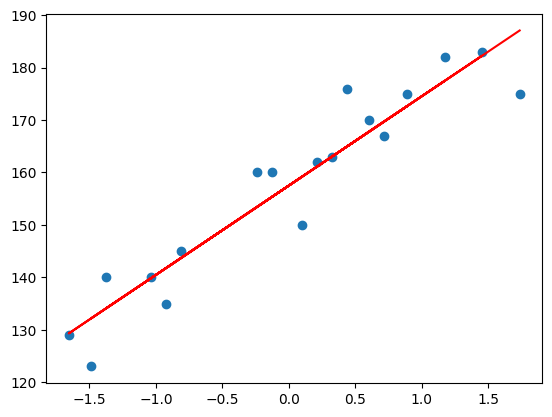

In [ ]:
## Best-Fit Line
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),color='r')

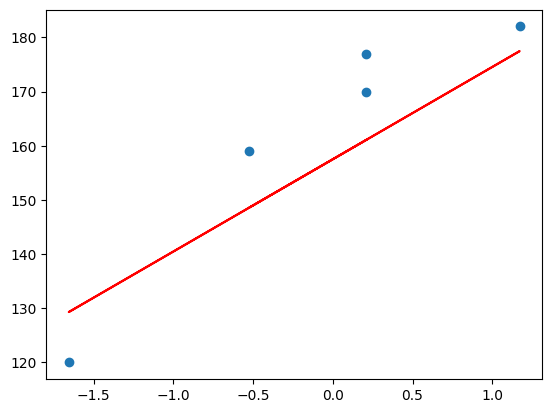

In [59]:
## Ploting Best fit line on testing data

y_pred_test = regressor.predict(X_test)
y_pred_test,y_test

plt.scatter(X_test,y_test)
plt.plot(X_test, regressor.predict(X_test),color='r')

In [62]:
# Performance Metrics
## MAE,MSE,RMSE
### R square and adjusted R square

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Square Error", mse)
print("Root Mean Square Error", rmse)


Mean Absolute Error: 9.822657814519232
Mean Square Error 109.77592599051664
Root Mean Square Error 10.477400726827081


In [64]:
## Accuracy of Model

from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred_test)
print("R2 Score:", score)

R2 Score: 0.776986986042344


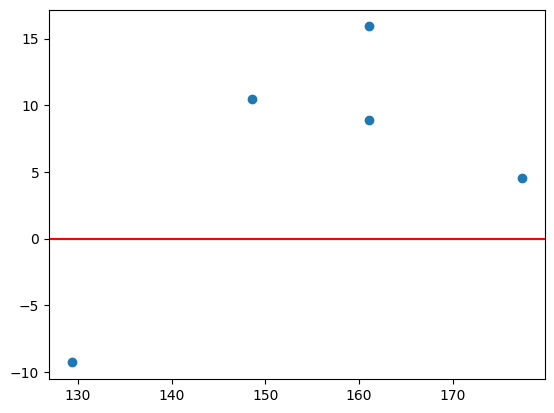

In [65]:
## Residuals
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.axhline(y=0, color='r')

In [68]:
# Plicking the Model

import pickle

pickle.dump(regressor, open('B:/SELF_LEARNING/artifacts/slr_model.pkl','wb'))
